In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from src.models.baseline import RandomForestModel, XGBoostModel
from src.utils.cross_validation import cross_validate_model, plot_cv_results
from src.utils.mlflow_utils import setup_mlflow, mlflow_run, log_metrics

setup_mlflow()
plt.rcParams["figure.dpi"] = 120
print("✅ Setup complete")


✅ MLflow ready (SQLite backend)
✅ Setup complete


In [2]:

# ── Cell 2: Rebuild feature matrix (same synthetic data as notebook 02) ────────
np.random.seed(42)
n_total, n_pos = 500, 60

def make_feature_rows(n, has_planet, seed_start=0):
    rows = []
    for i in range(n):
        np.random.seed(seed_start + i)
        period = np.random.uniform(5, 300)
        row = {
            "flux_mean":                1.0 + np.random.normal(0, 0.001),
            "flux_std":                 np.random.uniform(0.001, 0.003) if not has_planet else np.random.uniform(0.003, 0.012),
            "flux_median":              1.0 + np.random.normal(0, 0.001),
            "flux_min":                 1.0 - (np.random.uniform(0.008, 0.02) if has_planet else np.random.uniform(0.001, 0.005)),
            "flux_max":                 1.0 + np.random.uniform(0.001, 0.004),
            "flux_range":               np.random.uniform(0.01, 0.025) if has_planet else np.random.uniform(0.001, 0.008),
            "flux_mad":                 np.random.uniform(0.0005, 0.002),
            "flux_skew":                np.random.uniform(-1.2, -0.3) if has_planet else np.random.uniform(-0.3, 0.3),
            "flux_kurtosis":            np.random.uniform(1.5, 5.0) if has_planet else np.random.uniform(-0.5, 1.5),
            "frac_below_3sigma":        np.random.uniform(0.01, 0.05) if has_planet else np.random.uniform(0, 0.01),
            "n_dips_detected":          np.random.uniform(5, 15) if has_planet else np.random.uniform(0, 3),
            "dip_mean_depth":           np.random.uniform(0.005, 0.02) if has_planet else np.random.uniform(0, 0.002),
            "dip_depth_std":            np.random.uniform(0, 0.003),
            "dip_max_depth":            np.random.uniform(0.01, 0.025) if has_planet else np.random.uniform(0, 0.003),
            "dip_depth_consistency":    np.random.uniform(0, 0.3) if has_planet else np.random.uniform(0.3, 1.5),
            "folded_transit_depth":     np.random.uniform(0.005, 0.02) if has_planet else np.nan,
            "folded_transit_depth_ppm": np.random.uniform(5000, 20000) if has_planet else np.nan,
            "folded_transit_width_frac":np.random.uniform(0.01, 0.05) if has_planet else np.nan,
            "folded_symmetry":          np.random.uniform(0, 0.002) if has_planet else np.nan,
            "period_days":              period if has_planet else np.nan,
            "log_period":               np.log10(period) if has_planet else np.nan,
        }
        rows.append(row)
    return rows

rows = make_feature_rows(n_total - n_pos, False, 0) + make_feature_rows(n_pos, True, 1000)
features_df = pd.DataFrame(rows)
X = features_df.drop(columns=["label"] if "label" in features_df.columns else [])

# add labels
labels = np.array([0]*(n_total - n_pos) + [1]*n_pos)
X["label"] = labels
X_all = X.drop(columns=["label"])
y_all  = labels

print(f"Feature matrix: {X_all.shape} | Positive rate: {y_all.mean():.3f}")



Feature matrix: (500, 21) | Positive rate: 0.120


In [3]:

# ── Cell 3: 5-Fold CV — Random Forest ─────────────────────────────────────────
print("Running 5-fold CV for Random Forest...")
print("(Each fold trains a fresh model — this shows score variance)\n")

rf_params = dict(n_estimators=300, max_depth=15, min_samples_leaf=5)

rf_cv = cross_validate_model(
    model_class=RandomForestModel,
    model_params=rf_params,
    X=X_all,
    y=y_all,
    n_splits=5,
)

print(f"\nRandom Forest 5-Fold CV Results:")
print(f"  F1      : {rf_cv['f1_mean']:.4f} ± {rf_cv['f1_std']:.4f}")
print(f"  ROC-AUC : {rf_cv['roc_auc_mean']:.4f} ± {rf_cv['roc_auc_std']:.4f}")
print(f"  PR-AUC  : {rf_cv['ap_mean']:.4f} ± {rf_cv['ap_std']:.4f}")
print(f"\nPer-fold F1 scores: {[round(f['f1'],3) for f in rf_cv['fold_details']]}")



Running 5-fold CV for Random Forest...
(Each fold trains a fresh model — this shows score variance)


Random Forest 5-Fold CV Results:
  F1      : 1.0000 ± 0.0000
  ROC-AUC : 1.0000 ± 0.0000
  PR-AUC  : 1.0000 ± 0.0000

Per-fold F1 scores: [1.0, 1.0, 1.0, 1.0, 1.0]


In [4]:
# ── Cell 4: 5-Fold CV — XGBoost ───────────────────────────────────────────────
print("Running 5-fold CV for XGBoost...")

xgb_params = dict(n_estimators=200, max_depth=6, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, scale_pos_weight=8.3)

xgb_cv = cross_validate_model(
    model_class=XGBoostModel,
    model_params=xgb_params,
    X=X_all,
    y=y_all,
    n_splits=5,
)

print(f"\nXGBoost 5-Fold CV Results:")
print(f"  F1      : {xgb_cv['f1_mean']:.4f} ± {xgb_cv['f1_std']:.4f}")
print(f"  ROC-AUC : {xgb_cv['roc_auc_mean']:.4f} ± {xgb_cv['roc_auc_std']:.4f}")
print(f"  PR-AUC  : {xgb_cv['ap_mean']:.4f} ± {xgb_cv['ap_std']:.4f}")

Running 5-fold CV for XGBoost...

XGBoost 5-Fold CV Results:
  F1      : 0.9913 ± 0.0174
  ROC-AUC : 1.0000 ± 0.0000
  PR-AUC  : 1.0000 ± 0.0000


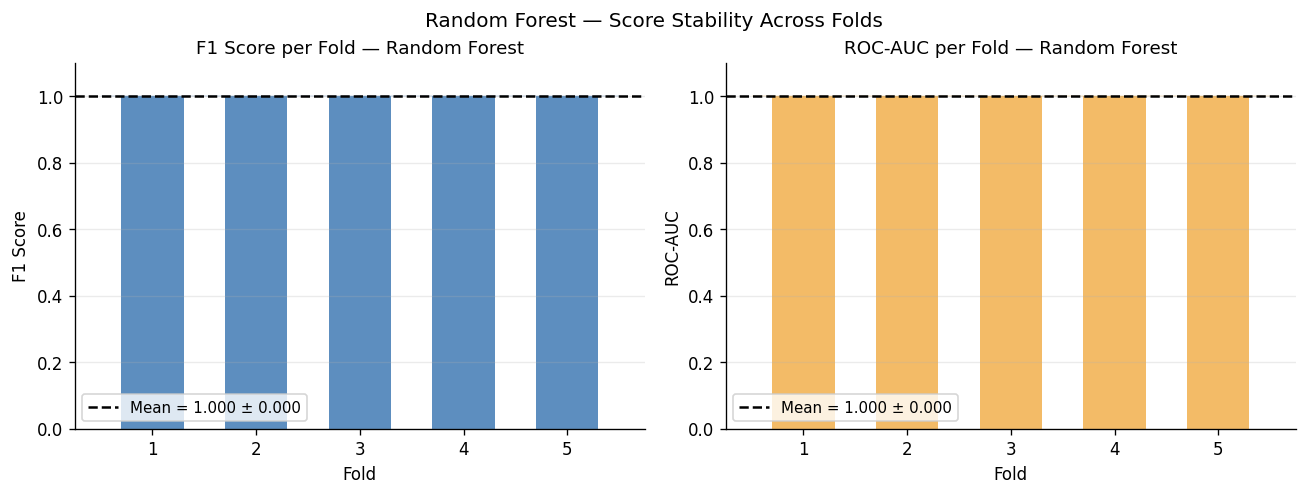

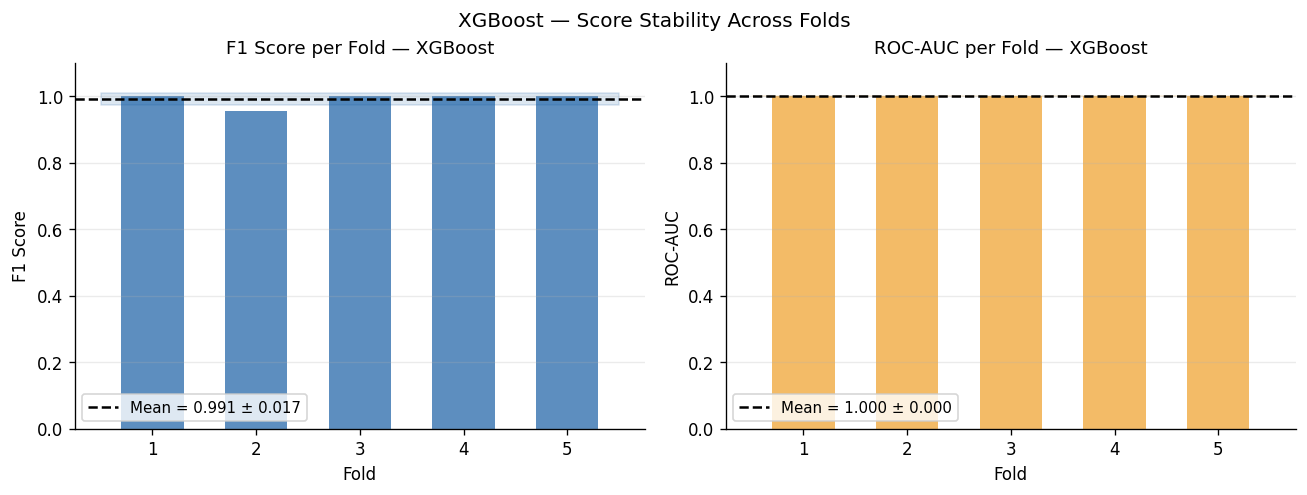

In [5]:
# ── Cell 5: Visualize CV stability ────────────────────────────────────────────
fig = plot_cv_results(rf_cv, "Random Forest")
plt.suptitle("Random Forest — Score Stability Across Folds", y=1.02, fontsize=12)
plt.show()

fig = plot_cv_results(xgb_cv, "XGBoost")
plt.suptitle("XGBoost — Score Stability Across Folds", y=1.02, fontsize=12)
plt.show()

# What to look for:
# - Low std (< 0.05) = model is stable = results are trustworthy
# - High std = results depend heavily on which data is in val set
#   = you need more data or a simpler model

In [6]:
#  ── Cell 6: CV comparison summary ─────────────────────────────────────────────
print("\n" + "="*55)
print("  CROSS-VALIDATION SUMMARY")
print("="*55)
print(f"{'Model':<20} {'F1 mean':>10} {'F1 std':>10} {'AUC mean':>10}")
print("-"*55)
print(f"{'Random Forest':<20} {rf_cv['f1_mean']:>10.4f} {rf_cv['f1_std']:>10.4f} {rf_cv['roc_auc_mean']:>10.4f}")
print(f"{'XGBoost':<20} {xgb_cv['f1_mean']:>10.4f} {xgb_cv['f1_std']:>10.4f} {xgb_cv['roc_auc_mean']:>10.4f}")
print("="*55)

winner = "XGBoost" if xgb_cv['f1_mean'] >= rf_cv['f1_mean'] else "Random Forest"
print(f"\n🏆 Better mean F1: {winner}")
print(f"\n📋 Copy these numbers into RESULTS.md cross-validation table")

# Log to MLflow
with mlflow_run("cv_comparison") as run:
    log_metrics({
        "rf_cv_f1_mean":  rf_cv["f1_mean"],
        "rf_cv_f1_std":   rf_cv["f1_std"],
        "xgb_cv_f1_mean": xgb_cv["f1_mean"],
        "xgb_cv_f1_std":  xgb_cv["f1_std"],
    })


  CROSS-VALIDATION SUMMARY
Model                   F1 mean     F1 std   AUC mean
-------------------------------------------------------
Random Forest            1.0000     0.0000     1.0000
XGBoost                  0.9913     0.0174     1.0000

🏆 Better mean F1: Random Forest

📋 Copy these numbers into RESULTS.md cross-validation table
